# 01 — Dataset Preparation & Statistics
## UniMatch: Arabic Student Advising Chatbot

### Dataset Description
- **Source:** College of Economics and Business — PTUK
- **Language:** Arabic
- **Columns:**
  - `السؤال` — Original question
  - `الجواب` — Answer
  - `السؤال بصياغة جديدة` — Rephrased question (used for evaluation)

### Notebook Output
- Cleaned dataset saved to `data/faq_clean.csv`
- Statistics report
- Distribution plots

## Cell 1 — Install Dependencies

In [1]:
!pip install -q pandas openpyxl matplotlib seaborn

## Cell 2 — Mount Drive & Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = '/content/drive/MyDrive/Student_chatbot/'
DATA_DIR = os.path.join(BASE_DIR, 'data/')
os.makedirs(DATA_DIR, exist_ok=True)

EXCEL_PATH = os.path.join(BASE_DIR, 'output.xlsx')

print(f'Excel file exists : {os.path.exists(EXCEL_PATH)}')
print(f'Data dir          : {DATA_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Excel file exists : True
Data dir          : /content/drive/MyDrive/Student_chatbot/data/


## Cell 3 — Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

print('Imports done ✅')

Imports done ✅


## Cell 4 — Load Raw Dataset

In [4]:
import os
df_index = pd.read_csv(os.path.join(DATA_DIR, 'faq_train.csv'))
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'faq_test_long.csv'))

NameError: name 'DATA_DIR' is not defined

In [ ]:
df_raw = pd.read_excel(EXCEL_PATH)
df_raw.columns = ['question', 'answer', 'question_alt']

print(f'Shape   : {df_raw.shape}')
print(f'Columns : {df_raw.columns.tolist()}')
display(df_raw.head(3))

Shape   : (288, 3)
Columns : ['question', 'answer', 'question_alt']


,question,answer,question_alt
0,متى تأسست كلية الاقتصاد والأعمال؟,تأسست كلية الاقتصاد والأعمال عام 2007.,في أي سنة أُنشئت كلية الاقتصاد والأعمال؟
1,ما الهدف من إنشاء كلية الاقتصاد والأعمال؟,تهدف كلية الاقتصاد والأعمال إلى إعداد وتأهيل خ...,ما الغرض الذي أُسست من أجله كلية الاقتصاد والأ...
2,كم عدد الأقسام في كلية الاقتصاد والأعمال؟,تضم كلية الاقتصاد والأعمال خمسة أقسام.,كم قسمًا تحتوي كلية الاقتصاد والأعمال؟


## Cell 5 — Raw Statistics (Before Cleaning)

In [ ]:
print('='*55)
print('  RAW DATASET STATISTICS (Before Cleaning)')
print('='*55)
print(f'  Total rows          : {len(df_raw):,}')
print(f'\n  Missing values:')
for col in df_raw.columns:
    print(f'    {col:20s}: {df_raw[col].isna().sum()}')
print(f'\n  Duplicate rows      : {df_raw.duplicated().sum()}')
print(f'  Duplicate questions : {df_raw["question"].duplicated().sum()}')
print('='*55)

  RAW DATASET STATISTICS (Before Cleaning)
  Total rows          : 288

  Missing values:
    question            : 7
    answer              : 8
    question_alt        : 8

  Duplicate rows      : 6
  Duplicate questions : 6


## Cell 6 — Preprocessing Function

In [ ]:
def preprocess_arabic(text):
    """
    Arabic text preprocessing:
    1. Strip whitespace
    2. Remove URLs
    3. Normalize Arabic characters (Alef, Ya, Ta Marbuta)
    4. Remove diacritics (Tashkeel)
    5. Normalize repeated characters
    6. Remove extra whitespace
    """
    if pd.isna(text):
        return ''
    text = str(text).strip()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub('[إأآ]', 'ا', text)
    text = re.sub('ى', 'ي', text)
    text = re.sub('ة', 'ه', text)
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Test
sample = df_raw['question'].iloc[0]
print(f'Original : {sample}')
print(f'Processed: {preprocess_arabic(sample)}')
print('\nPreprocessing function defined ✅')

Original : متى تأسست كلية الاقتصاد والأعمال؟
Processed: متي تاسست كليه الاقتصاد والاعمال؟

Preprocessing function defined ✅


## Cell 7 — Apply Preprocessing

In [ ]:
df = df_raw.copy()
df['question']     = df['question'].apply(preprocess_arabic)
df['answer']       = df['answer'].apply(preprocess_arabic)
df['question_alt'] = df['question_alt'].apply(preprocess_arabic)

before = len(df)
df = df[df['question'].str.len() > 0]
df = df[df['answer'].str.len() > 0]
df = df[df['question_alt'].str.len() > 0]
df = df.drop_duplicates(subset=['question'])
df = df.reset_index(drop=True)
after = len(df)

print(f'Before cleaning : {before}')
print(f'After cleaning  : {after}')
print(f'Removed         : {before - after}')
print('Preprocessing done ✅')

Before cleaning : 288
After cleaning  : 280
Removed         : 8
Preprocessing done ✅


## Cell 8 — Add Length Features

In [ ]:
df['q_word_count']   = df['question'].apply(lambda x: len(x.split()))
df['a_word_count']   = df['answer'].apply(lambda x: len(x.split()))
df['alt_word_count'] = df['question_alt'].apply(lambda x: len(x.split()))
df['q_char_count']   = df['question'].apply(len)
df['a_char_count']   = df['answer'].apply(len)

print('Length features added ✅')
display(df[['question', 'q_word_count', 'a_word_count']].head(5))

Length features added ✅


,question,q_word_count,a_word_count
0,متي تاسست كليه الاقتصاد والاعمال؟,5,6
1,ما الهدف من انشاء كليه الاقتصاد والاعمال؟,7,145
2,كم عدد الاقسام في كليه الاقتصاد والاعمال؟,7,6
3,ما هي الاقسام الموجوده في كليه الاقتصاد والاعمال؟,8,24
4,ما الهدف من دراسه تخصص العلوم الماليه والمصرفي...,9,43


## Cell 9 — Post-Cleaning Statistics

In [ ]:
print('='*55)
print('  DATASET STATISTICS (After Cleaning)')
print('='*55)
print(f'  Total FAQ pairs         : {len(df):,}')
print(f'\n  Question word count:')
print(f'    Min    : {df["q_word_count"].min()}')
print(f'    Max    : {df["q_word_count"].max()}')
print(f'    Mean   : {df["q_word_count"].mean():.1f}')
print(f'    Median : {df["q_word_count"].median():.1f}')
print(f'\n  Answer word count:')
print(f'    Min    : {df["a_word_count"].min()}')
print(f'    Max    : {df["a_word_count"].max()}')
print(f'    Mean   : {df["a_word_count"].mean():.1f}')
print(f'    Median : {df["a_word_count"].median():.1f}')
print('='*55)

  DATASET STATISTICS (After Cleaning)
  Total FAQ pairs         : 280

  Question word count:
    Min    : 1
    Max    : 16
    Mean   : 6.8
    Median : 6.0

  Answer word count:
    Min    : 1
    Max    : 154
    Mean   : 28.1
    Median : 19.0


## Cell 10 — Word Count Distribution Plot

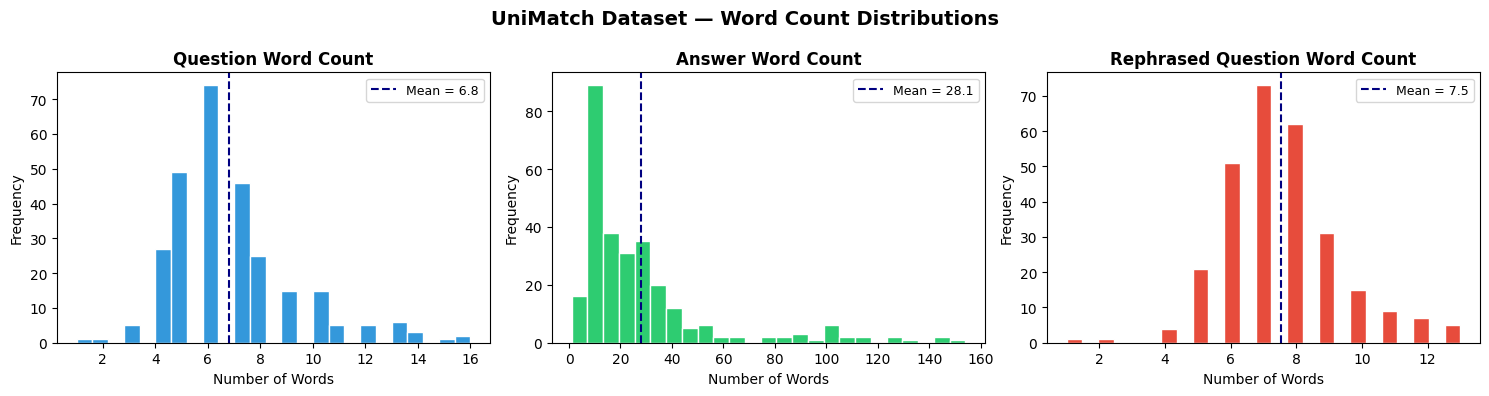

Saved ✅


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color, title in [
    (axes[0], 'q_word_count',   '#3498db', 'Question Word Count'),
    (axes[1], 'a_word_count',   '#2ecc71', 'Answer Word Count'),
    (axes[2], 'alt_word_count', '#e74c3c', 'Rephrased Question Word Count'),
]:
    ax.hist(df[col], bins=25, color=color, edgecolor='white')
    ax.axvline(df[col].mean(), color='navy', linestyle='--',
               label=f'Mean = {df[col].mean():.1f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Number of Words')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('UniMatch Dataset — Word Count Distributions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'word_count_distribution.png'), dpi=150)
plt.show()
print('Saved ✅')

## Cell 11 — Answer Length vs Question Length Scatter

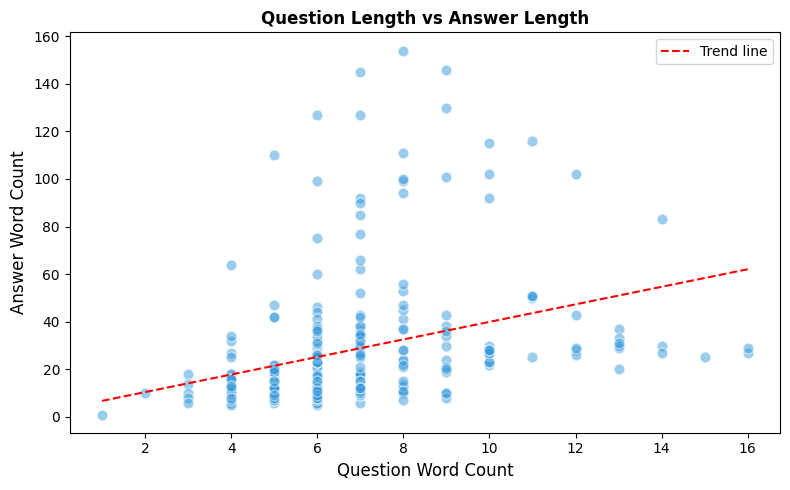

Saved ✅


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['q_word_count'], df['a_word_count'],
           alpha=0.5, color='#3498db', edgecolors='white', s=60)

z = np.polyfit(df['q_word_count'], df['a_word_count'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['q_word_count'].min(), df['q_word_count'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=1.5, label='Trend line')

ax.set_xlabel('Question Word Count', fontsize=12)
ax.set_ylabel('Answer Word Count', fontsize=12)
ax.set_title('Question Length vs Answer Length', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'length_scatter.png'), dpi=150)
plt.show()
print('Saved ✅')

## Cell 12 — Top 20 Most Frequent Words

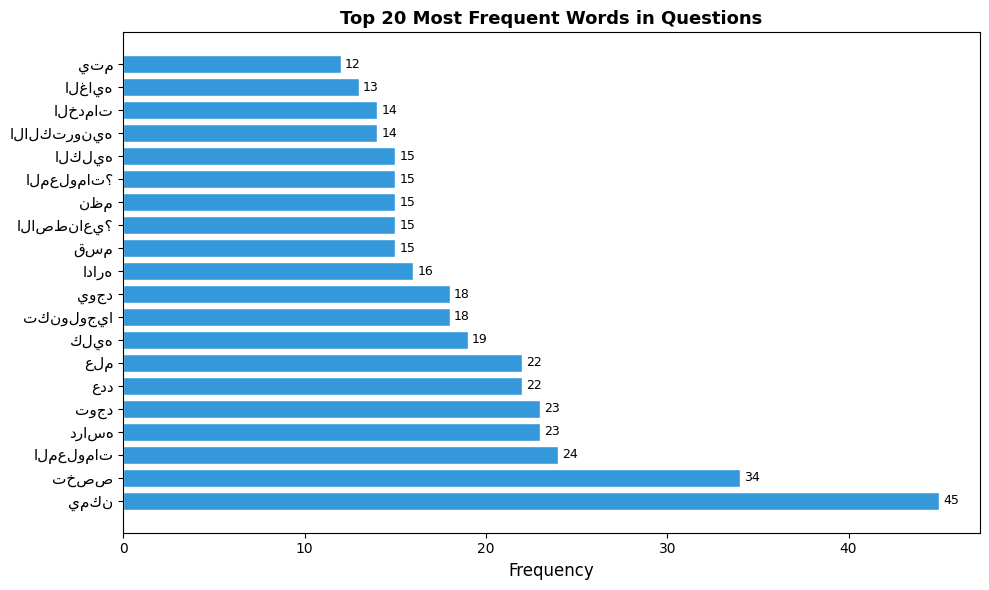

Saved ✅


In [ ]:
ARABIC_STOPS = {
    'من', 'في', 'على', 'إلى', 'عن', 'مع', 'هذا', 'هذه', 'التي', 'الذي',
    'كان', 'كانت', 'هو', 'هي', 'أن', 'ان', 'لا', 'ما', 'هل', 'كيف',
    'متى', 'أين', 'لم', 'قد', 'أو', 'و', 'ف', 'ب', 'ل', 'ك',
    'ال', 'وال', 'بال', 'ما', 'مع', 'هو', 'هي'
}

all_words = []
for q in df['question']:
    words = [w for w in q.split() if w not in ARABIC_STOPS and len(w) > 2]
    all_words.extend(words)

word_freq = Counter(all_words).most_common(20)
words_list, freqs_list = zip(*word_freq)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(words_list)), freqs_list,
               color='#3498db', edgecolor='white')
ax.set_yticks(range(len(words_list)))
ax.set_yticklabels(words_list, fontsize=11)
ax.set_xlabel('Frequency', fontsize=12)
ax.set_title('Top 20 Most Frequent Words in Questions',
             fontweight='bold', fontsize=13)
ax.bar_label(bars, padding=3, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'top_words.png'), dpi=150)
plt.show()
print('Saved ✅')

## Cell 13 — Summary Statistics Table

In [ ]:
stats_df = pd.DataFrame({
    'Metric': [
        'Total FAQ pairs',
        'Q: min words', 'Q: max words', 'Q: mean words',
        'A: min words', 'A: max words', 'A: mean words',
        'Q: min chars',  'Q: max chars',  'Q: mean chars',
    ],
    'Value': [
        len(df),
        df['q_word_count'].min(),
        df['q_word_count'].max(),
        round(df['q_word_count'].mean(), 2),
        df['a_word_count'].min(),
        df['a_word_count'].max(),
        round(df['a_word_count'].mean(), 2),
        df['q_char_count'].min(),
        df['q_char_count'].max(),
        round(df['q_char_count'].mean(), 2),
    ]
})
display(stats_df)
stats_df.to_csv(os.path.join(DATA_DIR, 'dataset_stats.csv'), index=False)

,Metric,Value
0,Total FAQ pairs,280.00
1,Q: min words,1.00
2,Q: max words,16.00
3,Q: mean words,6.80
4,A: min words,1.00
5,A: max words,154.00
6,A: mean words,28.14
7,Q: min chars,5.00
8,Q: max chars,100.00
9,Q: mean chars,39.49


## Cell 14 — Save Clean Dataset

In [ ]:
clean_path = os.path.join(DATA_DIR, 'faq_clean.csv')
df[['question', 'answer', 'question_alt']].to_csv(
    clean_path, index=False, encoding='utf-8-sig')

print('='*55)
print('  SAVED FILES')
print('='*55)
print(f'  faq_clean.csv              → {len(df)} rows')
print(f'  dataset_stats.csv')
print(f'  word_count_distribution.png')
print(f'  length_scatter.png')
print(f'  top_words.png')
print(f'\n  Saved to: {DATA_DIR}')
print('='*55)
print(f'\nNext → 02_method1_TFIDF.ipynb')

  SAVED FILES
  faq_clean.csv              → 280 rows
  dataset_stats.csv
  word_count_distribution.png
  length_scatter.png
  top_words.png

  Saved to: /content/drive/MyDrive/Student_chatbot/data/

Next → 02_method1_TFIDF.ipynb
